In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('./datasets/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Use all three classes for multi-class classification
df_multi = df.copy()

# Create numeric labels (0=Setosa, 1=Versicolor, 2=Virginica)
species_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
df_multi['label'] = df_multi['Species'].map(species_map)

# Use all 4 features
X = df_multi[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = df_multi['label'].values

# Normalize features (standardization: zero mean, unit variance)
feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0)
X_normalized = (X - feature_mean) / feature_std

# Shuffle data for better train/test split
np.random.seed(42)
indices = np.random.permutation(len(X_normalized))
X_shuffled = X_normalized[indices]
y_shuffled = y[indices]

# Train/test split (80/20)
split_idx = int(0.8 * len(X_normalized))
X_train = X_shuffled[:split_idx]
y_train = y_shuffled[:split_idx]
X_test = X_shuffled[split_idx:]
y_test = y_shuffled[split_idx:]

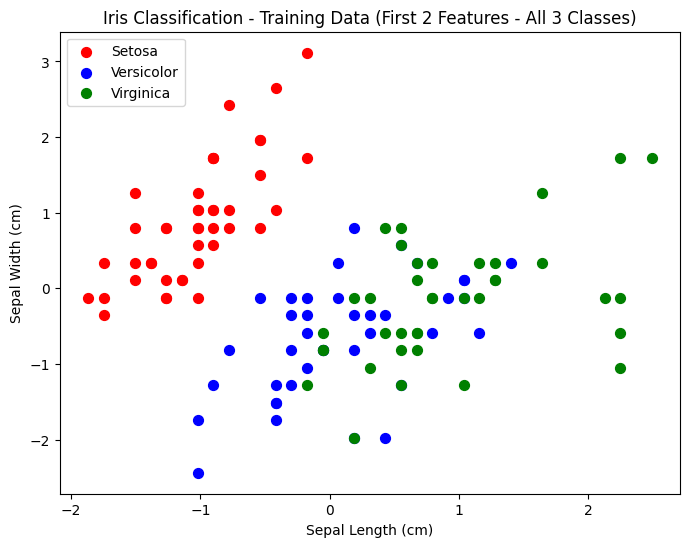

In [4]:
# Visualize first two features (2D projection of 4D data)
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='red', label='Setosa', s=50)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='blue', label='Versicolor', s=50)
plt.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1], color='green', label='Virginica', s=50)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(loc='upper left')
plt.title('Iris Classification - Training Data (First 2 Features - All 3 Classes)')
plt.show()

In [5]:
def softmax(z):
    """Compute softmax for multi-class classification"""
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Subtract max for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [6]:
def cost_function(X, y, W, b):
    """Compute cross-entropy cost for multi-class classification"""
    m = X.shape[0]
    num_classes = W.shape[1]
    epsilon = 1e-15
    
    # Compute logits and softmax
    z = np.dot(X, W) + b
    probs = softmax(z)
    
    # Create one-hot encoded labels
    y_one_hot = np.eye(num_classes)[y]
    
    # Cross-entropy cost
    cost = (-1 / m) * np.sum(y_one_hot * np.log(probs + epsilon))
    return cost

In [7]:
def gradient_function(X, y, W, b):
    """Compute gradients for multi-class classification"""
    m = X.shape[0]
    num_classes = W.shape[1]
    
    # Compute logits and softmax
    z = np.dot(X, W) + b
    probs = softmax(z)
    
    # Create one-hot encoded labels
    y_one_hot = np.eye(num_classes)[y]
    
    # Compute gradients
    error = probs - y_one_hot
    grad_W = np.dot(X.T, error) / m
    grad_b = np.sum(error, axis=0) / m
    
    return grad_b, grad_W

In [8]:
def predict(X, W, b):
    """Predict class with highest probability for multi-class classification"""
    z = np.dot(X, W) + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

In [ ]:
def gradient_descent(X, y, X_test, y_test, alpha, epochs):
    n = X.shape[1]
    num_classes = len(np.unique(y))
    
    # Initialize weights for multi-class
    W = np.zeros((n, num_classes))
    b = np.zeros(num_classes)
    
    for i in range(epochs):
        grad_b, grad_W = gradient_function(X, y, W, b)
        W -= alpha * grad_W
        b -= alpha * grad_b
        
        if i % 100 == 0:
            cost = cost_function(X, y, W, b)
            predictions = predict(X_test, W, b)
            accuracy = np.mean(predictions == y_test) * 100
            print(f"Epoch: {i} | Cost: {cost:.6f} | Accuracy: {accuracy:.2f}%")
    
    return W, b

In [10]:
learning_rate = 0.01
epochs = 1000

final_W, final_b = gradient_descent(X_train, y_train, X_test, y_test, learning_rate, epochs)
predictions = predict(X_test, final_W, final_b)
accuracy = np.mean(predictions == y_test) * 100
print(f"\nFinal Testing Accuracy: {accuracy:.2f}%")

# Print per-class accuracy
class_names = ['Setosa', 'Versicolor', 'Virginica']
for class_idx in range(3):
    class_mask = y_test == class_idx
    if np.sum(class_mask) > 0:
        class_accuracy = np.mean(predictions[class_mask] == y_test[class_mask]) * 100
        print(f"{class_names[class_idx]} Accuracy: {class_accuracy:.2f}%")

Epoch: 0 | Cost: 1.088341 | Accuracy: 80.00%
Epoch: 100 | Cost: 0.625371 | Accuracy: 83.33%
Epoch: 200 | Cost: 0.506251 | Accuracy: 83.33%
Epoch: 300 | Cost: 0.449480 | Accuracy: 83.33%
Epoch: 400 | Cost: 0.414249 | Accuracy: 83.33%
Epoch: 500 | Cost: 0.389327 | Accuracy: 86.67%
Epoch: 600 | Cost: 0.370248 | Accuracy: 86.67%
Epoch: 700 | Cost: 0.354837 | Accuracy: 86.67%
Epoch: 800 | Cost: 0.341895 | Accuracy: 90.00%
Epoch: 900 | Cost: 0.330707 | Accuracy: 93.33%

Final Testing Accuracy: 93.33%
Setosa Accuracy: 100.00%
Versicolor Accuracy: 90.91%
Virginica Accuracy: 91.67%


In [18]:
# 3D Visualization with Decision Boundary - First three features (Interactive)
import plotly.graph_objects as go
from IPython.display import HTML, display

# Prepare data for all three classes
setosa_idx = y_train == 0
versicolor_idx = y_train == 1
virginica_idx = y_train == 2

# Create figure
fig = go.Figure()

# Add Setosa scatter plot
fig.add_trace(go.Scatter3d(
    x=X_train[setosa_idx, 0],
    y=X_train[setosa_idx, 1],
    z=X_train[setosa_idx, 2],
    mode='markers',
    marker=dict(size=5, color='red', opacity=0.7),
    name='Setosa'
))

# Add Versicolor scatter plot
fig.add_trace(go.Scatter3d(
    x=X_train[versicolor_idx, 0],
    y=X_train[versicolor_idx, 1],
    z=X_train[versicolor_idx, 2],
    mode='markers',
    marker=dict(size=5, color='blue', opacity=0.7),
    name='Versicolor'
))

# Add Virginica scatter plot
fig.add_trace(go.Scatter3d(
    x=X_train[virginica_idx, 0],
    y=X_train[virginica_idx, 1],
    z=X_train[virginica_idx, 2],
    mode='markers',
    marker=dict(size=5, color='green', opacity=0.7),
    name='Virginica'
))

# Create decision boundary surface (single color)
x1_min, x1_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
x2_min, x2_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 15), 
                        np.linspace(x2_min, x2_max, 15))
xx3 = np.ones_like(xx1) * X_train[:, 2].mean()

# Get predictions for the surface
grid_3d = np.c_[xx1.ravel(), xx2.ravel(), xx3.ravel()]
x4_mean = X_train[:, 3].mean()
grid_full_3d = np.c_[grid_3d, np.ones(grid_3d.shape[0]) * x4_mean]
Z_3d = predict(grid_full_3d, final_W, final_b).reshape(xx1.shape)

# Add decision boundary surface in a single color
fig.add_trace(go.Surface(
    x=xx1,
    y=xx2,
    z=xx3,
    surfacecolor=np.zeros_like(Z_3d),
    colorscale=[[0, 'orange'], [1, 'orange']],
    showscale=False,
    opacity=0.7,
    name='Decision Surface'
))

# Update layout
fig.update_layout(
    title='Iris Classification - 3D Visualization (All 3 Classes)',
    scene=dict(
        xaxis_title='Sepal Length',
        yaxis_title='Sepal Width',
        zaxis_title='Petal Length'
    ),
    width=1000,
    height=800,
    showlegend=True
)

# Render without requiring nbformat
display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))